In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\clark\OneDrive\Desktop\drowsiness_project


In [2]:
from pathlib import Path

FRAMES_ROOT = PROJECT_ROOT / "processed" / "FRAMES"

for cls in ["alert", "low_vigilant", "drowsy"]:
    (FRAMES_ROOT / cls).mkdir(parents=True, exist_ok=True)

print("Folders created!")

Folders created!


In [3]:
import shutil      #copying nthu alert datset to frames
from pathlib import Path
from tqdm import tqdm

nthu_root = PROJECT_ROOT / "processed" / "NTHU"

# alert
for img in tqdm((nthu_root / "alert").glob("*.jpg")):
    dst = FRAMES_ROOT / "alert" / f"nthu_{img.name}"
    shutil.copy2(img, dst)

# drowsy
for img in tqdm((nthu_root / "drowsy").glob("*.jpg")):
    dst = FRAMES_ROOT / "drowsy" / f"nthu_{img.name}"
    shutil.copy2(img, dst)

print("NTHU copied.")

0it [00:00, ?it/s]

29646it [00:39, 756.36it/s] 
0it [00:00, ?it/s]

NTHU copied.


In [4]:
for img in tqdm((nthu_root / "drowsy").rglob("*.jpg")): #copying nthu drowsy dataset to frames
    dst = FRAMES_ROOT / "drowsy" / f"nthu_{img.name}"
    shutil.copy2(img, dst)

print("NTHU drowsy copied.")

35275it [00:40, 869.18it/s] 

NTHU drowsy copied.


In [5]:
from pathlib import Path

nthu_root = PROJECT_ROOT / "processed" / "NTHU"

alert_count = len(list((nthu_root / "alert").glob("*.jpg")))
drowsy_count = len(list((nthu_root / "drowsy").rglob("*.jpg")))

print(f"NTHU Alert images  : {alert_count}")
print(f"NTHU Drowsy images : {drowsy_count}")
print(f"Total NTHU images  : {alert_count + drowsy_count}")

print("FRAMES Alert        :", len(list((FRAMES_ROOT / "alert").glob("*.jpg"))))
print("FRAMES Drowsy       :", len(list((FRAMES_ROOT / "drowsy").glob("*.jpg"))))
print("FRAMES Low Vigilant :", len(list((FRAMES_ROOT / "low_vigilant").glob("*.jpg"))))

NTHU Alert images  : 29646
NTHU Drowsy images : 35275
Total NTHU images  : 64921
FRAMES Alert        : 30081
FRAMES Drowsy       : 35399
FRAMES Low Vigilant : 0


In [6]:
import shutil
from tqdm import tqdm

mendeley_root = PROJECT_ROOT / "processed" / "MENDELEY"

# Copy alert images
for img in tqdm((mendeley_root / "alert").glob("*.jpg")):
    dst = FRAMES_ROOT / "alert" / f"mendeley_{img.name}"
    shutil.copy2(img, dst)

# Copy drowsy images
for img in tqdm((mendeley_root / "drowsy").glob("*.jpg")):
    dst = FRAMES_ROOT / "drowsy" / f"mendeley_{img.name}"
    shutil.copy2(img, dst)

print("Mendeley copied successfully!")

435it [00:00, 1246.62it/s]
124it [00:00, 1124.60it/s]

Mendeley copied successfully!


In [7]:
print("Alert images:",
      len(list((FRAMES_ROOT / "alert").glob("*.jpg"))))

print("Drowsy images:",
      len(list((FRAMES_ROOT / "drowsy").glob("*.jpg"))))

print("Low vigilant images:",
      len(list((FRAMES_ROOT / "low_vigilant").glob("*.jpg"))))

Alert images: 30081
Drowsy images: 35399
Low vigilant images: 0


In [8]:
for cls in ["alert", "drowsy", "low_vigilant"]:
    print(
        cls,
        len(list((FRAMES_ROOT / cls).glob("*.jpg")))
    )

alert 30081
drowsy 35399
low_vigilant 0


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = []

for cls in ["alert", "drowsy"]:
    for img in (FRAMES_ROOT / cls).glob("*.jpg"):
        data.append({
            "filepath": str(img),
            "label": cls
        })

df = pd.DataFrame(data)

print(df["label"].value_counts())

label
drowsy    35399
alert     30081
Name: count, dtype: int64


In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

train_df.to_csv(PROJECT_ROOT / "train.csv", index=False)
val_df.to_csv(PROJECT_ROOT / "val.csv", index=False)
test_df.to_csv(PROJECT_ROOT / "test.csv", index=False)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 52384
Val: 6548
Test: 6548


In [11]:
print("\nTrain")
print(train_df["label"].value_counts())

print("\nValidation")
print(val_df["label"].value_counts())

print("\nTest")
print(test_df["label"].value_counts())


Train
label
drowsy    28319
alert     24065
Name: count, dtype: int64

Validation
label
drowsy    3540
alert     3008
Name: count, dtype: int64

Test
label
drowsy    3540
alert     3008
Name: count, dtype: int64


In [12]:
import pandas as pd

train_df = pd.read_csv(PROJECT_ROOT / "train.csv")
val_df = pd.read_csv(PROJECT_ROOT / "val.csv")
test_df = pd.read_csv(PROJECT_ROOT / "test.csv")

In [13]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
import sys
print(sys.executable)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\venv\Scripts\python.exe


In [15]:
from pathlib import Path
import os

print(os.getcwd())

c:\Users\clark\OneDrive\Desktop\drowsiness_project\notebooks


In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\clark\OneDrive\Desktop\drowsiness_project


In [17]:
import importlib
import src.dataset

importlib.reload(src.dataset)

from src.dataset import DrowsinessDataset

In [18]:
import src.dataset as ds
print(dir(ds))

['Dataset', 'DrowsinessDataset', 'Image', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__']


In [19]:
train_dataset = DrowsinessDataset(
    train_df,
    train_transform
)

val_dataset = DrowsinessDataset(
    val_df,
    val_transform
)

test_dataset = DrowsinessDataset(
    test_df,
    val_transform
)

In [20]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [21]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([0, 0, 0, 1, 1, 1, 1, 1, 0, 1])


In [22]:
import torch
import torch.nn as nn
from torchvision import models

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce RTX 5060 Laptop GPU


In [24]:
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

In [25]:
for param in model.features[:5].parameters():
    param.requires_grad = False

In [26]:
model.classifier = nn.Sequential(
    nn.Dropout(0.3),

    nn.Linear(1280, 512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(512, 2)
)

In [27]:
model = model.to(device)

In [28]:
import torch

weights = torch.tensor(
    [1.09, 0.93],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

In [29]:
optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3
)

In [30]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [31]:
print(model)
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [32]:
print(device)
print(torch.cuda.is_available())

cuda
True


In [33]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(
    PROJECT_ROOT / "results" / "tensorboard"
)

In [34]:
import os

os.makedirs(
    PROJECT_ROOT / "models" / "checkpoints",
    exist_ok=True
)

In [35]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    loss = running_loss / len(loader)
    acc = correct / total

    return loss, acc

In [36]:
def validate(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    loss = running_loss / len(loader)
    acc = correct / total

    return loss, acc

In [38]:
NUM_EPOCHS = 50
PATIENCE = 10

best_val_loss = float("inf")
patience_counter = 0
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    scheduler.step(val_loss)

    print(
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    writer.add_scalar(
        "Loss/train",
        train_loss,
        epoch
    )

    writer.add_scalar(
        "Loss/val",
        val_loss,
        epoch
    )

    writer.add_scalar(
        "Accuracy/train",
        train_acc,
        epoch
    )

    writer.add_scalar(
        "Accuracy/val",
        val_acc,
        epoch
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            PROJECT_ROOT
            / "models"
            / "checkpoints"
            / "best_cnn.pth"
        )

        print("✅ Best model saved.")

    else:
        patience_counter += 1

        print(
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break


Epoch 1/50


100%|██████████| 205/205 [00:14<00:00, 14.40it/s]


Train Loss: 0.2725 Train Acc: 0.8790
Val Loss: 0.1703 Val Acc: 0.9261
✅ Best model saved.

Epoch 2/50


100%|██████████| 205/205 [00:17<00:00, 11.49it/s]


Train Loss: 0.1713 Train Acc: 0.9308
Val Loss: 0.1096 Val Acc: 0.9568
✅ Best model saved.

Epoch 3/50


...

Train Loss: 0.0113 Train Acc: 0.9959
Val Loss: 0.0216 Val Acc: 0.9936
No improvement (5/10)

Epoch 49/50


100%|██████████| 205/205 [00:14<00:00, 14.51it/s]


Train Loss: 0.0095 Train Acc: 0.9961
Val Loss: 0.0213 Val Acc: 0.9939
No improvement (6/10)

Epoch 50/50


100%|██████████| 205/205 [00:13<00:00, 15.18it/s]

Train Loss: 0.0099 Train Acc: 0.9964
Val Loss: 0.0217 Val Acc: 0.9934
No improvement (7/10)


In [39]:
test_loss, test_acc = validate(
    model,
    test_loader
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")

100%|██████████| 205/205 [00:13<00:00, 15.43it/s]

Test Loss: 0.0238
Test Acc : 0.9936


In [40]:
torch.save(
    model.state_dict(),
    PROJECT_ROOT / "models" / "checkpoints" / "last_cnn.pth"
)

In [41]:
model.load_state_dict(
    torch.load(
        PROJECT_ROOT / "models" / "checkpoints" / "best_cnn.pth",
        map_location=device
    )
)

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [43]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Alert", "Drowsy"]
    )
)

              precision    recall  f1-score   support

       Alert       0.99      0.99      0.99      3008
      Drowsy       0.99      0.99      0.99      3540

    accuracy                           0.99      6548
   macro avg       0.99      0.99      0.99      6548
weighted avg       0.99      0.99      0.99      6548



In [44]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=["Alert", "Drowsy"]
)

with open(
    PROJECT_ROOT / "results" / "metrics" / "cnn_report.txt",
    "w"
) as f:
    f.write(report)

In [45]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[2983   25]
 [  22 3518]]


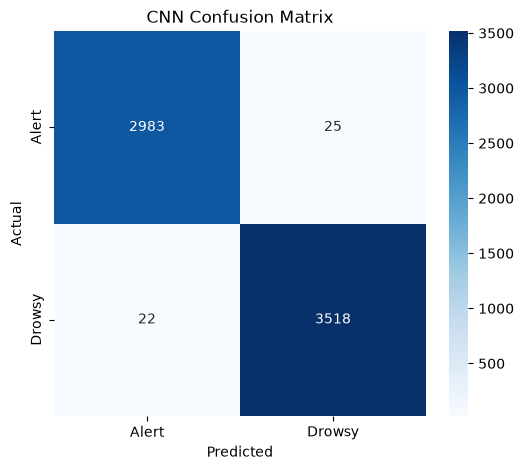

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Alert", "Drowsy"],
    yticklabels=["Alert", "Drowsy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

In [49]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Alert", "Drowsy"],
    yticklabels=["Alert", "Drowsy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.savefig(
    PROJECT_ROOT / "results" / "plots" / "cnn_confusion_matrix.png"
)

plt.close()

In [50]:
with open(
    PROJECT_ROOT / "results" / "metrics" / "cnn_test_metrics.txt",
    "w"
) as f:
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")